# Preprocessing & Modeling – Insurance Risk Prediction

This notebook performs data preprocessing, feature transformation, and sets up the dataset for machine learning model training and evaluation.


In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import joblib

## Step 1: Load Synthetic Data

In [2]:
input_path = '../data/insurance_preprocessed.csv'
output_path = '../data/synth_insurance_data.csv'
image_output = '../outputs/images'
data = pd.read_csv(input_path)

In [3]:
data.head()

,age,annual_income,credit_score,number_of_dependents,years_employed,vehicle_value,annual_premium,monthly_expenses,savings_amount,loan_amount,...,has_children,has_previous_claims,is_smoker,is_diabetic,owns_multiple_policies,has_health_insurance,is_student,has_loyalty_discount,attended_defensive_driving,claim_status
0,56,64718.28,635.0,4,4,17579.70,907.11,2248.14,19895.23,7579.48,...,0,0,0,0,0,0,1,1,1,0
1,69,62079.69,679.0,1,30,20325.51,611.93,1786.30,-856.06,14302.00,...,0,0,1,0,0,0,1,1,0,0
2,46,59810.34,688.0,1,10,30371.51,1732.22,3046.37,4761.09,4865.10,...,0,0,0,0,1,0,1,1,0,0
3,32,61890.01,706.0,1,37,31262.27,1294.60,63.05,5253.40,8833.24,...,1,0,0,1,0,0,0,1,1,0
4,60,54442.50,708.0,2,3,11578.69,1062.81,2302.37,4475.28,12255.02,...,0,0,0,1,0,0,1,0,1,0


In [4]:
data.shape

(10100, 40)

## Step 2: Handle Missing Values & Duplicates

We impute:
- `credit_score` (numerical) with median
- `education_level`, `job_title`, `health_status` (categorical/ordinal) with mode


In [5]:
# Fill missing numerical values
data['credit_score'].fillna(data['credit_score'].median(), inplace=True)

# Fill missing categorical/ordinal values
for col in ['education_level', 'job_title', 'health_status']:
    data[col].fillna(data[col].mode()[0], inplace=True)

In [6]:
# Drop exact duplicates
before = data.shape[0]
data.drop_duplicates(inplace=True)
after = data.shape[0]
print(f"Removed {before - after} duplicate rows")

Removed 84 duplicate rows


## Step 3: Encode Categorical & Ordinal Features

- Ordinal features like `health_status`, `driving_record`, etc. are mapped numerically
- Nominal categorical features are one-hot encoded


In [7]:
ordinal_mappings = {
    'health_status': {'Poor': 0, 'Fair': 1, 'Good': 2, 'Very Good': 3, 'Excellent': 4},
    'driving_record': {'Very Bad': 0, 'Bad': 1, 'Average': 2, 'Good': 3, 'Excellent': 4},
    'risk_appetite': {'Low': 0, 'Medium': 1, 'High': 2},
    'credit_utilization_band': {'Low': 0, 'Medium': 1, 'High': 2, 'Very High': 3},
}

for col, mapping in ordinal_mappings.items():
    data[col] = data[col].map(mapping)


In [8]:
nominal_cols = [
    'gender', 'marital_status', 'education_level', 'job_title', 'region',
    'policy_type', 'employment_type', 'payment_frequency',
    'communication_preference', 'relationship_to_policyholder', 'home_ownership'
]

data = pd.get_dummies(data, columns=nominal_cols, drop_first=True)


## Step 4: Scale Numeric Features

We use StandardScaler to normalize numeric features (excluding the target).


In [9]:
from sklearn.preprocessing import StandardScaler

# Exclude target from scaling
numeric_cols = [col for col in data.select_dtypes(include=['int64', 'float64']).columns if col != 'claim_status']

scaler = StandardScaler()
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])


In [10]:
data.to_csv(output_path, index=False)

## Step 5: Train-Test Split

We use an 80-20 stratified split to maintain class balance.


In [11]:
from sklearn.model_selection import train_test_split

# Split
X = data.drop(columns='claim_status')
y = data['claim_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (8012, 697)
Test shape: (2004, 697)


## Step 6: Modeling

In [12]:
model_results = {}

def train_model(name, model, X_train, y_train, X_test, y_test, param_grid=None, do_tuning=False, plot_roc=False):
    if do_tuning and param_grid:
        print(f"Tuning {name} with GridSearchCV...")
        grid = GridSearchCV(model, param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
        grid.fit(X_train, y_train)
        model = grid.best_estimator_
        print(f"Best params for {name}: {grid.best_params_}")
    else:
        print(f"Training {name} without hyperparameter tuning...")
        model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)
    cm = confusion_matrix(y_test, preds)
    report = classification_report(y_test, preds, output_dict=True)

    # Store results
    model_results[name] = {
        'model': model,
        'preds': preds,
        'probs': probs,
        'roc_auc': auc,
        'report': report,
        'confusion_matrix': cm
    }

    print(f"\n{name} ROC AUC: {auc:.4f}")
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_test, preds))

    if plot_roc:
        fpr, tpr, _ = roc_curve(y_test, probs)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")
        plt.savefig(f"{image_output}/{name}_ROC_AUC.png")

    return model


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
import lightgbm as lgb

# Compute imbalance ratio for XGBoost
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

# Define 4 base models
model_dict = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42),
    "XGBoost": xgb.XGBClassifier(scale_pos_weight=scale_pos, use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": lgb.LGBMClassifier(class_weight='balanced', random_state=42)
}


Training Logistic Regression without hyperparameter tuning...

Logistic Regression ROC AUC: 0.5392
Confusion Matrix:
 [[1215  623]
 [  98   68]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.66      0.77      1838
           1       0.10      0.41      0.16       166

    accuracy                           0.64      2004
   macro avg       0.51      0.54      0.46      2004
weighted avg       0.86      0.64      0.72      2004

Training Decision Tree without hyperparameter tuning...

Decision Tree ROC AUC: 0.5705
Confusion Matrix:
 [[1105  733]
 [  79   87]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.60      0.73      1838
           1       0.11      0.52      0.18       166

    accuracy                           0.59      2004
   macro avg       0.52      0.56      0.45      2004
weighted avg       0.86      0.59      0.69      2004

Training XGBoost wit

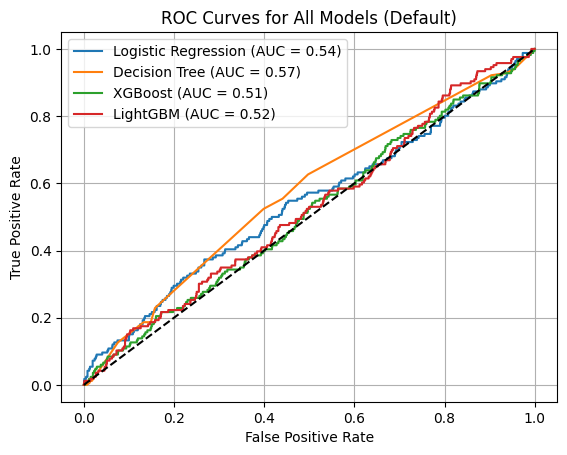

In [14]:
model_results = {}  # Reset before running

for name, model in model_dict.items():
    train_model(
        name=name,
        model=model,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        do_tuning=False,
        plot_roc=True  # Optional: True to show ROC for each
    )

# Plot overall ROC comparison
import matplotlib.pyplot as plt

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models (Default)")
plt.legend()
plt.grid(True)
plt.savefig(f"{image_output}/ROC_Curve_before_tuning.png")
plt.show()

In [15]:
# Sort model_results by AUC
sorted_models = sorted(model_results.items(), key=lambda x: x[1]['roc_auc'], reverse=True)

# Show sorted list
print(" Model Performance (ROC AUC):\n")
for name, result in sorted_models:
    print(f"{name}: AUC = {result['roc_auc']:.4f}")


 Model Performance (ROC AUC):

Decision Tree: AUC = 0.5705
Logistic Regression: AUC = 0.5392
LightGBM: AUC = 0.5234
XGBoost: AUC = 0.5127


Tuning Decision Tree (Tuned) with GridSearchCV...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best params for Decision Tree (Tuned): {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

Decision Tree (Tuned) ROC AUC: 0.5518
Confusion Matrix:
 [[926 912]
 [ 69  97]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.50      0.65      1838
           1       0.10      0.58      0.17       166

    accuracy                           0.51      2004
   macro avg       0.51      0.54      0.41      2004
weighted avg       0.86      0.51      0.61      2004



DecisionTreeClassifier(class_weight='balanced', max_depth=3, random_state=42)

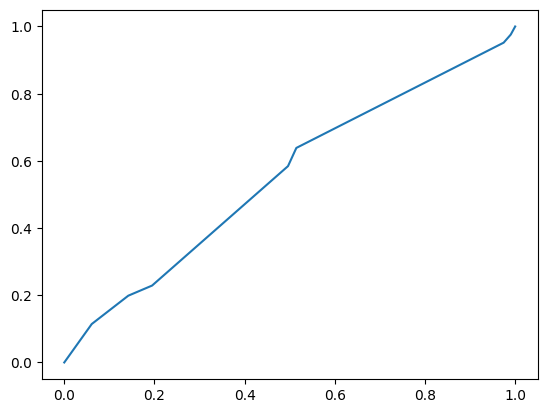

In [16]:
# Param grid for Decision Tree
param_grid_dt = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Tune Decision Tree
train_model(
    name="Decision Tree (Tuned)",
    model=model_dict["Decision Tree"],
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    param_grid=param_grid_dt,
    do_tuning=True,
    plot_roc=True
)


Tuning XGBoost (Tuned) with GridSearchCV...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best params for XGBoost (Tuned): {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}

XGBoost (Tuned) ROC AUC: 0.5845
Confusion Matrix:
 [[1017  821]
 [  75   91]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.55      0.69      1838
           1       0.10      0.55      0.17       166

    accuracy                           0.55      2004
   macro avg       0.52      0.55      0.43      2004
weighted avg       0.86      0.55      0.65      2004



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

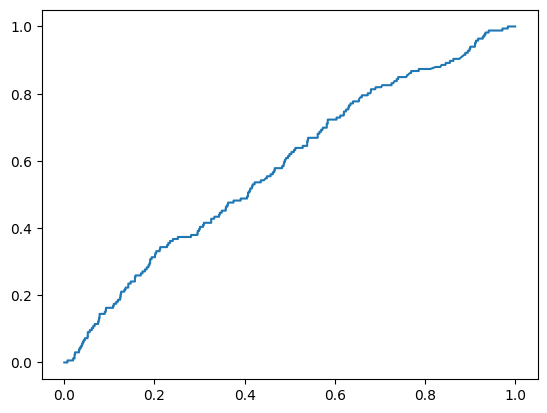

In [17]:
param_grid_xgb = {
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.01],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}
# Tune XGBoost
train_model(
    name="XGBoost (Tuned)",
    model=model_dict["XGBoost"],
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    param_grid=param_grid_xgb,
    do_tuning=True,
    plot_roc=True
)

In [18]:
joblib.dump(model_results["XGBoost (Tuned)"]['model'], "../models/xgboost_tuned_model.pkl")

['../models/xgboost_tuned_model.pkl']

## Preprocessing Summary

We completed:
- Imputation of missing values
- Removal of duplicates
- Encoding of ordinal and nominal features
- Feature scaling
- Stratified train-test split
- Fit Models
- Select two best models
- Use HyperParameter Tuning to select the best model
- save the best model

We’re now ready to fit machine learning models in the next notebook.

Next: `Model Explainability & Inference.ipynb`
